In [582]:
# Librerías para visión artificial
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

folder = Path('./Rostros/')

In [583]:
cv2.data.haarcascades

'c:\\Users\\Pablo Perez\\anaconda3\\envs\\DSRNArtificiales\\Lib\\site-packages\\cv2\\data\\'

In [584]:
!dir "c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\cv2\data"

 El volumen de la unidad C no tiene etiqueta.
 El n�mero de serie del volumen es: ADFA-52C0

 Directorio de c:\Users\Pablo Perez\anaconda3\envs\DSRNArtificiales\Lib\site-packages\cv2\data

25/04/2026  09:30 a. m.    <DIR>          .
25/04/2026  09:30 a. m.    <DIR>          ..
25/04/2026  09:30 a. m.           341,406 haarcascade_eye.xml
25/04/2026  09:30 a. m.           601,661 haarcascade_eye_tree_eyeglasses.xml
25/04/2026  09:30 a. m.           411,388 haarcascade_frontalcatface.xml
25/04/2026  09:30 a. m.           382,918 haarcascade_frontalcatface_extended.xml
25/04/2026  09:30 a. m.           676,709 haarcascade_frontalface_alt.xml
25/04/2026  09:30 a. m.           540,616 haarcascade_frontalface_alt2.xml
25/04/2026  09:30 a. m.         2,689,040 haarcascade_frontalface_alt_tree.xml
25/04/2026  09:30 a. m.           930,127 haarcascade_frontalface_default.xml
25/04/2026  09:30 a. m.           476,827 haarcascade_fullbody.xml
25/04/2026  09:30 a. m.           195,369 haarcascade_

In [585]:
# Cargando el modelo preentrenado
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt.xml")

In [586]:
#Estamos usando archivos locales
#from google.colab import drive
#drive.mount('/content/drive')

(1600, 1200, 3)


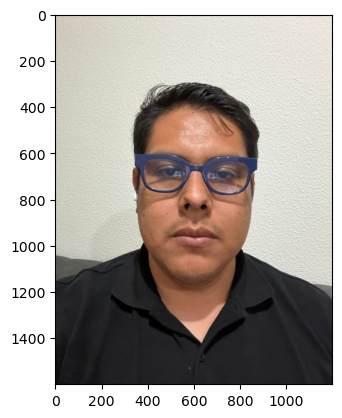

In [587]:
# Lectura de la imagen
ruta = 'Rostros/'
img = cv2.imread(ruta + 'PEPP_1.JPG')
print(img.shape)
# Conversión de formato
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img, cmap = "Accent")
plt.show()

In [588]:
# Detección de rostros
rostros = face_cascade.detectMultiScale(img, 1.3, 3)
print(rostros[0][0])

280


## Colocar el cuadro delimitador del rostro

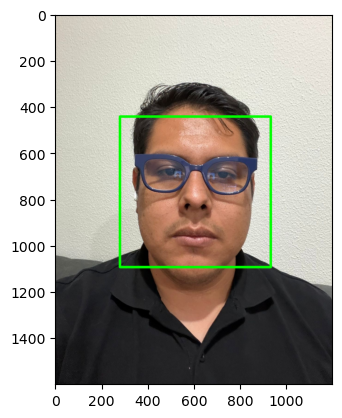

In [589]:
img_copy = np.copy(img)
cv2.rectangle(img_copy, (rostros[0][0],rostros[0][1]), (rostros[0][0]+rostros[0][2],rostros[0][1]+rostros[0][3]), (0,255,0),10)
plt.imshow(img_copy, cmap='Accent')
plt.show()

## Creación de datos de entrenamiento

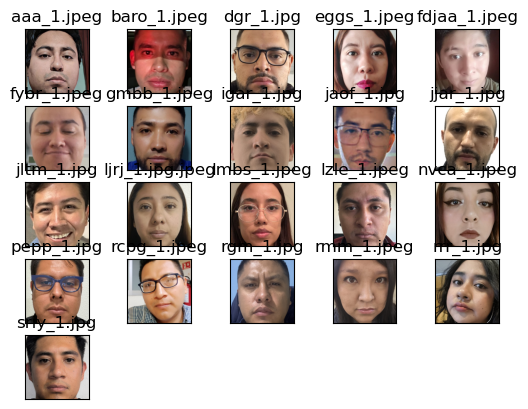

In [590]:
# Base de entrenamiento con 1 imágen por persona a color
imagenes = [ str.lower(f.name) for f in folder.glob('*_1.*') if f.is_file() ]

etiquetas = list(range( len(imagenes) ))
x_train = []
y_train = []
# Deteccion de rostros
for i in range( len(imagenes) ):
  img = cv2.imread(ruta+imagenes[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  rostros = face_cascade.detectMultiScale(img, 1.3, 3)
  if len(rostros) > 0:
    x, y, w, h = rostros[0]
    rostro = img[y:y+h, x:x+w, :]
    # Adjuntamos imágen y etiqueta
    rostro = cv2.resize(rostro, (694, 694)) #consideramos un 
    x_train.append(rostro) #metodo append añade elementos a listas
    y_train.append(etiquetas[i])
    
    plt.subplot(5, int ( np.ceil( len(imagenes) / 5  ) ) , i + 1, xticks = [], yticks = [])
    plt.imshow(rostro, cmap = 'Accent')
    plt.title(imagenes[i])
plt.show()

In [591]:
# Convertimos a arreglos
x_train = np.array(x_train)
y_train = np.array(y_train)

In [592]:
x_train.shape

(21, 694, 694, 3)

In [593]:
# Aplanamos las imágenes
x_train = x_train.reshape(21, 694*694*3)

In [594]:
x_train.shape

(21, 1444908)

## Creación del modelo

In [595]:
from sklearn.neighbors import KNeighborsClassifier

In [596]:
# Construcción del clasificador
clasificador = KNeighborsClassifier(n_neighbors=1, p=1) # Euclidiana
clasificador.fit(x_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


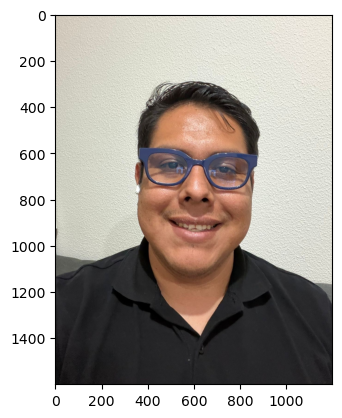

[[274 412 672 672]]


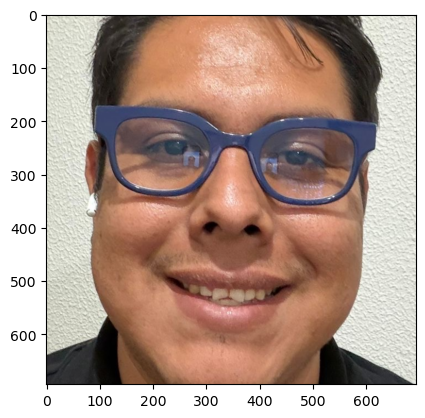

In [597]:
# Prueba del modelo
imgTest = cv2.imread(ruta+'pepp_2.jpg')
# Conversión de formato
imgTest = cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB)
plt.imshow(imgTest, cmap = 'Accent')
plt.show()
# Detección de rostros
rostro = face_cascade.detectMultiScale(imgTest, 1.3, 3)
print(rostro)
# Selección del rostro
for (x, y, w, h) in rostro:
  rostroTest = imgTest[y:y+h, x:x+w, :]
  rostroTest = cv2.resize(rostroTest, (694,694))
plt.imshow(rostroTest, cmap = 'Accent')
plt.show()


In [598]:
# Clasificación
persona = clasificador.predict(rostroTest.reshape(1, 694*694*3))
print('El rostro pertenece a: ', imagenes[persona[0]])

El rostro pertenece a:  pepp_1.jpg


Error al hacer match de rostro entre rrr y nvca
[[ 819 1709 1549 1549]]


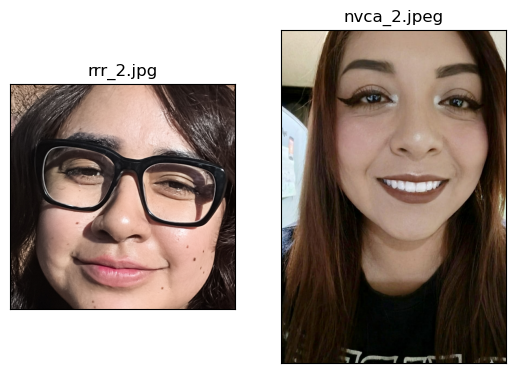

In [604]:
imagenes2 = [ str.lower(f.name) for f in folder.glob('*_2.*') if f.is_file() ]

for i in range( len(imagenes2) ):
    imgTest = cv2.imread(ruta+imagenes2[i])
    # Conversión de formato
    imgTest = cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB)
    # Detección de rostros
    rostros = face_cascade.detectMultiScale(imgTest, 1.3, 3)
    # Selección del rostro
    
    if len(rostros) > 0:
        for (x, y, w, h) in rostros:
            rostroTest = imgTest[y:y+h, x:x+w, :]
            rostroTest = cv2.resize(rostroTest, (694,694))
            
        persona = clasificador.predict(rostroTest.reshape(1, 694*694*3))
        
        nombreOri = imagenes2[i].split(".")[0][0:-2]
        nombreMatch = imagenes[persona[0]].split(".")[0][0:-2]

        if nombreOri != nombreMatch:
            
            print("Error al hacer match de rostro entre", nombreOri, "y", nombreMatch)
            print(rostros)
            imgTest = cv2.imread(ruta+imagenes2[persona[0]])
            imgTest = cv2.cvtColor(imgTest, cv2.COLOR_BGR2RGB)
            plt.subplot(1, 2 , 1, xticks = [], yticks = [])
            plt.imshow(rostroTest, cmap = 'Accent')
            plt.title( imagenes2[i] )
            plt.subplot(1, 2 , 2, xticks = [], yticks = [])
            plt.imshow(imgTest, cmap = 'Accent')
            plt.title(imagenes2[persona[0]])
            plt.show()
